<a href="https://colab.research.google.com/github/FOFM030711/Caminata-aleatoria-1D/blob/main/MOVIMIENTO_BROWNIAC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MOVIMIENTO BROWNIAC**

*Seudocódigo*

1. $dt=\frac{T}{L}$
2. $W_0=0$
3. Para $i=0$ a $L-1$
4. Calcule un $\xi_i\sim N (0,1)$
5. $W_{i+1}=W_i+ \sqrt {dt}\xi _1$
6. Terminar

**ACTIVIDAD**
* Programnar el seudocódigo y gráficar una trayectoria para $T=1$ y $L=100$
* Gráficar en el mismo panel $100$ trayectorias junto con $f(t)=\sqrt t $
* Comentarios y conclusiones

Procedamos a programar el seudocódigo

In [6]:
import numpy as np
import matplotlib.pyplot as plt

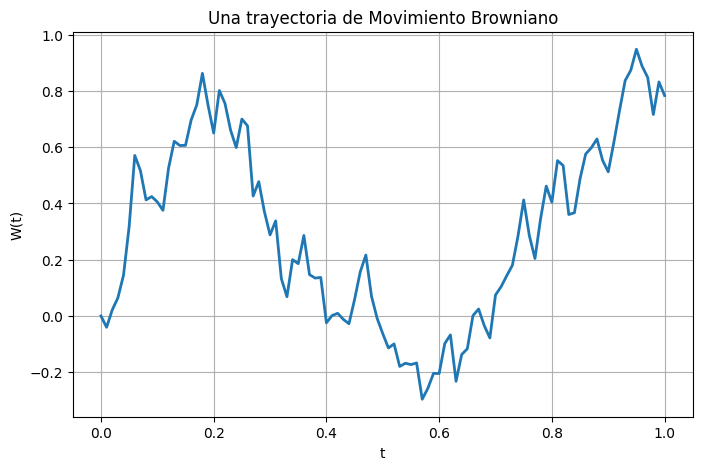

In [7]:


# Parámetros
T = 1
L = 100

# Paso temporal
dt = T / L

# Vector de tiempos
t = np.linspace(0, T, L + 1)

# Movimiento Browniano
W = np.zeros(L + 1)

for i in range(L):
    xi = np.random.normal(0, 1)
    W[i + 1] = W[i] + np.sqrt(dt) * xi

# Gráfica
plt.figure(figsize=(8,5))
plt.plot(t, W, lw=2)
plt.title("Una trayectoria de Movimiento Browniano")
plt.xlabel("t")
plt.ylabel("W(t)")
plt.grid(True)
plt.show()

Ahora, grafiquemos en el mismo panel $100$ trayectorias junto con $f(t)=\sqrt t $

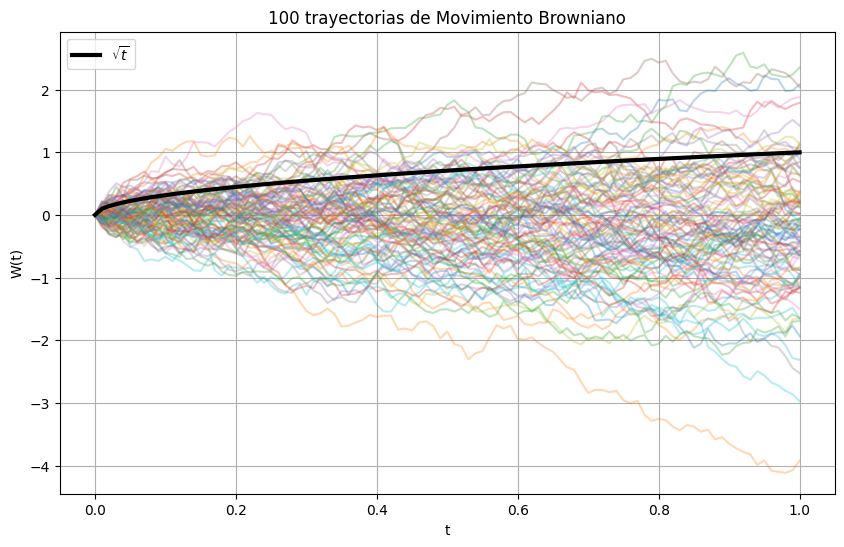

In [8]:

T = 1
L = 100
N = 100

dt = T / L
t = np.linspace(0, T, L + 1)

# Incrementos gaussianos
dW = np.sqrt(dt) * np.random.randn(N, L)

# Trayectorias
W = np.cumsum(dW, axis=1)

# Agregar W0=0
W = np.column_stack((np.zeros(N), W))

plt.figure(figsize=(10,6))

for k in range(N):
    plt.plot(t, W[k], alpha=0.3)

plt.plot(t, np.sqrt(t), 'k', lw=3, label=r'$\sqrt{t}$')

plt.title("100 trayectorias de Movimiento Browniano")
plt.xlabel("t")
plt.ylabel("W(t)")
plt.legend()
plt.grid(True)
plt.show()

Comentarios y conclusiones
El movimiento browniano comienza en W(0)=0 y presenta fluctuaciones aleatorias continuas.
Los incrementos

W(t+Δt)−W(t)
son independientes y siguen una distribución normal

N(0,Δt).
Aunque cada trayectoria es continua, son extremadamente irregulares; no son diferenciables en ningún punto.
La dispersión de las trayectorias aumenta con el tiempo. De hecho,

Var(W(t))=t,
por lo que la desviación estándar es

t​.
La curva f(t)=t​ representa precisamente la escala típica de las fluctuaciones del proceso. Se observa que muchas trayectorias permanecen dentro de un rango comparable a ±t​, aunque algunas pueden alejarse más debido al carácter aleatorio del movimiento.
Al aumentar el número de trayectorias se aprecia mejor cómo la nube de caminos se ensancha conforme crece t, reflejando el aumento de la varianza.
Si tu profesor espera una interpretación más teórica, también puedes añadir que el movimiento browniano es la base matemática de muchos modelos en física (difusión de partículas) y finanzas (modelo de precios de activos).

**Cuando simulamos una trayectoria, suele ser util refinarlo**

Dado $$\{t_i, W_i\}^L _{i=0}$$



$$t_{i+\frac{1}{2}} :=
\frac{1}{2} (t_i + t_{i+1})$$




$$W_{i+\frac{1}{2}}=\frac{1}{2} (W_i+W_{i+1})+\frac{1}{2} \sqrt {st} \xi_i$$, donde $\xi_i\sim N(0,1)$

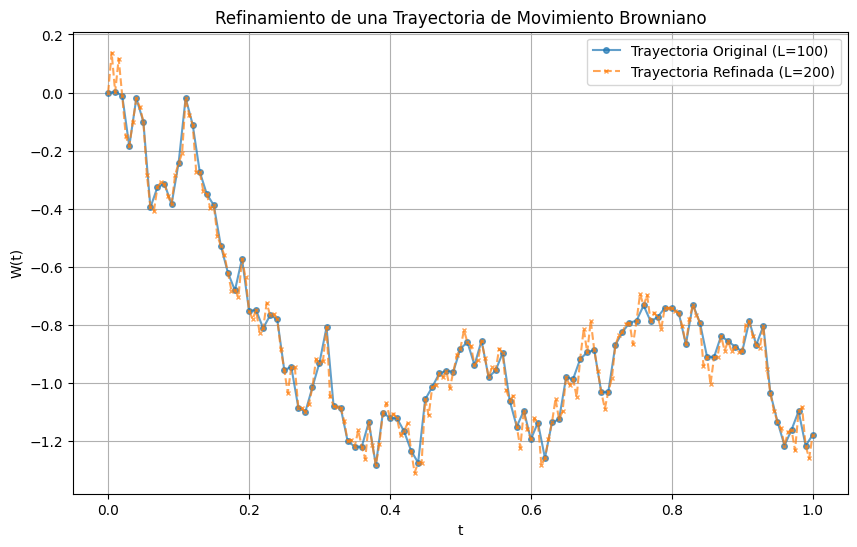

In [10]:

# Refinar la trayectoria
L_refined = 2 * L  # Duplicar el número de pasos para la trayectoria refinada
t_refined = np.zeros(L_refined + 1)
W_refined = np.zeros(L_refined + 1)

# Rellenar los puntos conocidos de la trayectoria original
t_refined[::2] = t_original
W_refined[::2] = W_original

# Calcular los puntos intermedios usando la fórmula proporcionada
# W_{i+1/2} = 0.5 * (W_i + W_{i+1}) + 0.5 * sqrt(dt_interval) * xi_i
for i in range(L):
    t_i = t_original[i]
    t_i_plus_1 = t_original[i+1]
    W_i = W_original[i]
    W_i_plus_1 = W_original[i+1]

    # t_{i+1/2} = 0.5 * (t_i + t_{i+1})
    t_i_half = 0.5 * (t_i + t_i_plus_1)

    # dt_interval es la diferencia de tiempo entre t_i y t_{i+1}
    dt_interval = t_i_plus_1 - t_i # Esto es igual al 'dt' original = T/L

    # xi_i ~ N(0,1)
    xi_i = np.random.normal(0, 1)

    # W_{i+1/2} = 0.5 * (W_i + W_{i+1}) + 0.5 * sqrt(dt_interval) * xi_i
    # Se asume que 'st' en la fórmula del usuario es un error tipográfico y se refiere a 'dt_interval'
    W_i_half = 0.5 * (W_i + W_i_plus_1) + 0.5 * np.sqrt(dt_interval) * xi_i

    # Asignar los valores calculados al array refinado
    t_refined[2*i + 1] = t_i_half
    W_refined[2*i + 1] = W_i_half

# Graficar la trayectoria original y la refinada
plt.figure(figsize=(10, 6))
plt.plot(t_original, W_original, 'o-', label='Trayectoria Original (L=100)', alpha=0.7, markersize=4)
plt.plot(t_refined, W_refined, 'x--', label=f'Trayectoria Refinada (L={L_refined})', alpha=0.7, markersize=3)
plt.title('Refinamiento de una Trayectoria de Movimiento Browniano')
plt.xlabel('t')
plt.ylabel('W(t)')
plt.legend()
plt.grid(True)
plt.show()